### Group 4

- YaroslavKuzmin
- Yevhen Nezghovorov
- Hlieb Nikoniuk
- Tymur Tleuberlin



**Getting started in Python**

In [42]:
# Hashtag sign # is used for comments - the code in this line will not be executed

# First you need to download the libraries to work with
import pandas as pd # Import the pandas library with the short name pd
# pandas is a library for data analysis in Python
import io # Import the io module to work with various files and data streams
import requests # Import the requests library to perform HTTP requests in Python

**Load data:** Assignment — convert file to dataframe df_Gas.

In [46]:
# Loading external data (in Colab: click Browse to locate "Gas_Stations.xlsx")
try:
    from google.colab import files
    uploaded = files.upload()
except ImportError:
    pass

Saving Gas_Stations.xlsx to Gas_Stations.xlsx


In [ ]:
# Load dataset into dataframe df_Gas
df_Gas = pd.read_excel("Gas_Stations.xlsx")
df_Gas.head()

In [47]:
print(df_Gas.head())

   Week  Sales    TV  Radio  Gas, volume  Gas, price in Eurocents  \
0    30  26268  90.0   75.0        65196                   109.08   
1    31  24304  90.0   75.0        64789                   105.36   
2    32  25680  15.0    8.5        65901                   107.31   
3    33  24494   0.0    0.0        65474                   107.99   
4    34  24423   0.0    0.0        65706                   109.30   

   Temperature  Rain  ExtraDayOff  Percent1_2Visits  
0         29.3   0.0            1               5.9  
1         28.1   3.6            1               5.9  
2         26.9   4.8            1               3.2  
3         28.9   5.6            1               3.2  
4         27.0   8.5            1               3.2  


In [48]:
# Get the descriptive statistics for the Gas Stations dataset
print(df_Gas.describe())

            Week         Sales          TV       Radio   Gas, volume  \
count  97.000000     97.000000   97.000000   97.000000     97.000000   
mean   26.536082  23000.268041   39.587629   80.871134  62888.525773   
std    15.611202   2478.026754   70.527440  101.934652   2357.016034   
min     1.000000  18969.000000    0.000000    0.000000  56259.000000   
25%    13.000000  21001.000000    0.000000    0.000000  61754.000000   
50%    27.000000  22829.000000    0.000000    0.000000  63209.000000   
75%    40.000000  24423.000000   37.500000  205.000000  64700.000000   
max    52.000000  28441.000000  225.000000  260.000000  68549.000000   

       Gas, price in Eurocents  Temperature       Rain  ExtraDayOff  \
count                97.000000    97.000000  97.000000    97.000000   
mean                115.871649    17.508247  11.704124     0.443299   
std                   8.241223     6.247894   6.669394     0.499355   
min                 101.460000     9.100000   0.000000     0.000000

- Sales show moderate volatility, demand is stable.
- TV and Radio spending are highly skewed, concentrated on few weeks only.
- Gas volume varies less than gas price, indicating inelastic demand.
- Extra day off occurs in less than half of the weeks.

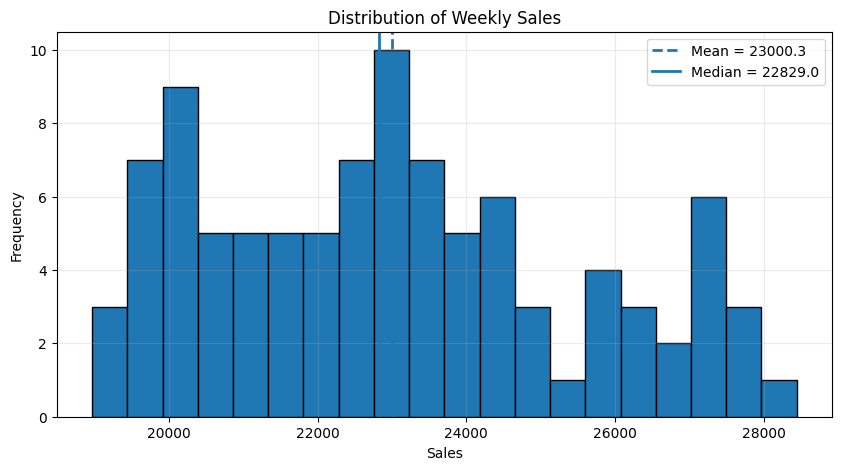

In [49]:
import matplotlib.pyplot as plt

sales = df_Gas['Sales']

plt.figure(figsize=(10, 5))
plt.hist(sales, bins=20, edgecolor='black')

# Reference lines
plt.axvline(sales.mean(), linestyle='--', linewidth=2, label=f"Mean = {sales.mean():.1f}")
plt.axvline(sales.median(), linestyle='-', linewidth=2, label=f"Median = {sales.median():.1f}")

plt.title('Distribution of Weekly Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()


The mean is a bit higher than the median, so the distribution is slightly right-skewed. We can say that sales are stable in general.


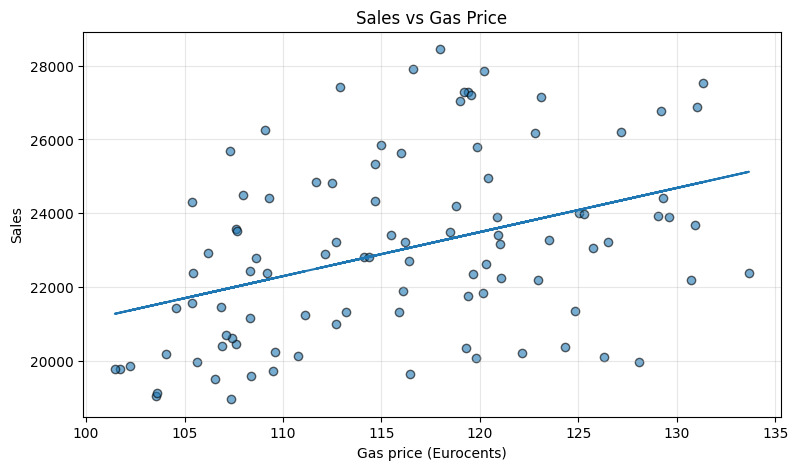

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Scatter plot: Sales vs Gas Price (price sensitivity)

plt.figure(figsize=(9, 5))
plt.scatter(
    df_Gas['Gas, price in Eurocents'],
    df_Gas['Sales'],
    alpha=0.6,
    edgecolor='black'
)

# Add a simple linear trend line
z = np.polyfit(df_Gas['Gas, price in Eurocents'], df_Gas['Sales'], 1)
p = np.poly1d(z)
plt.plot(df_Gas['Gas, price in Eurocents'], p(df_Gas['Gas, price in Eurocents']))

plt.title('Sales vs Gas Price')
plt.xlabel('Gas price (Eurocents)')
plt.ylabel('Sales')
plt.grid(True, alpha=0.3)
plt.show()

Sales slightly increase as gas prices rise, but the relationship is weak and noisy.

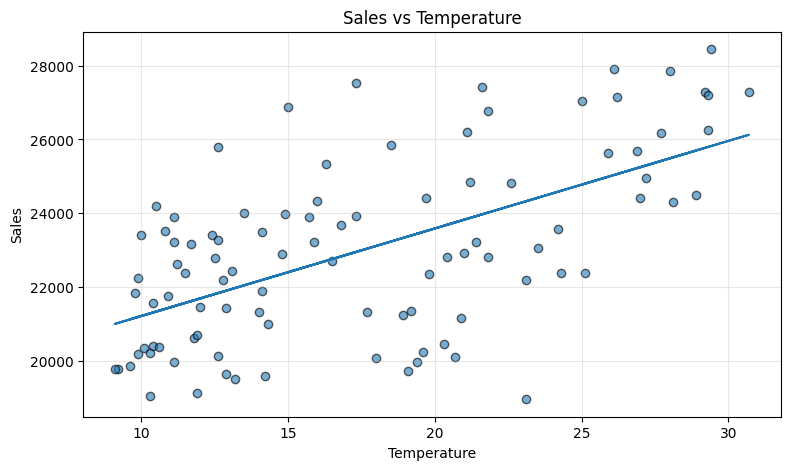

In [50]:
# Scatter plot: Sales vs Temperature

plt.figure(figsize=(9, 5))

plt.scatter(
    df_Gas['Temperature'],
    df_Gas['Sales'],
    alpha=0.6,
    edgecolor='black'
)

# Add linear trend line
z = np.polyfit(df_Gas['Temperature'], df_Gas['Sales'], 1)
p = np.poly1d(z)
plt.plot(df_Gas['Temperature'], p(df_Gas['Temperature']))

plt.title('Sales vs Temperature')
plt.xlabel('Temperature')
plt.ylabel('Sales')
plt.grid(True, alpha=0.3)
plt.show()

Sales tend to be higher in warmer weeks, showing a clear positive relationship with temperature.

In [ ]:
# Build a correlogram for Gas Stations dataset

import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix (numeric columns only)
corr = df_Gas.corr(numeric_only=True)

# Create a correlogram
sns.heatmap(
    corr,
    xticklabels=corr.columns,
    yticklabels=corr.columns,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlogram of Gas Stations Variables')
plt.show()

- Sales are strongly linked with temperature. Rain has a clear negative relationship.
- TV and Radio are highly correlated with each other, suggesting joint campaigns.
- Gas price shows only a weak link to sales.
- Extra day off is positively related to sales, but not a main driver.

In [51]:
import statsmodels.api as sm

# OLS regression for Gas Stations dataset
# Dependent variable: Sales
# Explanatory variables: price, advertising, weather, calendar effect

X = df_Gas[['Gas, price in Eurocents', 'TV', 'Radio', 'Temperature', 'ExtraDayOff']]
Y = df_Gas['Sales']

# Add intercept
X = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(Y, X)
results = model.fit()

# Show results
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.592
Model:                            OLS   Adj. R-squared:                  0.569
Method:                 Least Squares   F-statistic:                     26.38
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           2.21e-16
Time:                        16:03:55   Log-Likelihood:                -851.76
No. Observations:                  97   AIC:                             1716.
Df Residuals:                      91   BIC:                             1731.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    8

### OLS Regression Results

- The model explains about 56 percent of sales variation. (R^2 ≈ 59%)
- Temperature and extra day off have the strongest positive effects on sales.
- Gas price and ad spend are positive and statistically significant.
- Radio advertising is not statistically significant.
- Some multicollinearity may be present, but results remain stable.

In [53]:
# More difficult part (Gas Stations):
# Split into train (80%) and test (20%)
# Compare Linear Regression vs Random Forest using RMSE

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Define X (features) and Y (target)
X = df_Gas[['TV', 'Radio', 'Gas, volume', 'Gas, price in Eurocents',
            'Temperature', 'Rain', 'ExtraDayOff', 'Percent1_2Visits']]
Y = df_Gas['Sales']

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=0
)

# Linear Regression
model_lr = LinearRegression()
model_lr.fit(X_train, Y_train)

Y_pred_lr = model_lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(Y_test, Y_pred_lr))

# Random Forest
model_rf = RandomForestRegressor(random_state=0)
model_rf.fit(X_train, Y_train)

Y_pred_rf = model_rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(Y_test, Y_pred_rf))

# Results
print("RMSE Linear Regression:", rmse_lr)
print("RMSE Random Forest:", rmse_rf)

if rmse_lr < rmse_rf:
    print("Linear Regression performs better.")
else:
    print("Random Forest performs better.")

RMSE Linear Regression: 949.8830728849025
RMSE Random Forest: 1445.2539260109274
Linear Regression performs better.


Linear regression gives lower prediction error than random forest, suggesting the relationships are mostly linear or dataset is too small for a complex model.